In [10]:
import os 
print(os.listdir("Data"))

['processed', 'raw']


In [11]:
import os
print(os.listdir("Data/processed"))

['fund_master_clean.csv', 'investor_transactions_clean.csv', 'nav_history_clean.csv', 'scheme_performance_clean.csv']


In [12]:
fund_master = pd.read_csv("Data/processed/fund_master_clean.csv")
nav_history = pd.read_csv("Data/processed/nav_history_clean.csv")
investor_trans = pd.read_csv("Data/processed/investor_transactions_clean.csv")
performance = pd.read_csv("Data/processed/scheme_performance_clean.csv")

print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("Investor Transactions:", investor_trans.shape)
print("Performance:", performance.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Investor Transactions: (32778, 13)
Performance: (40, 19)


In [13]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [14]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [15]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

print(nav_history.info())

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB
None


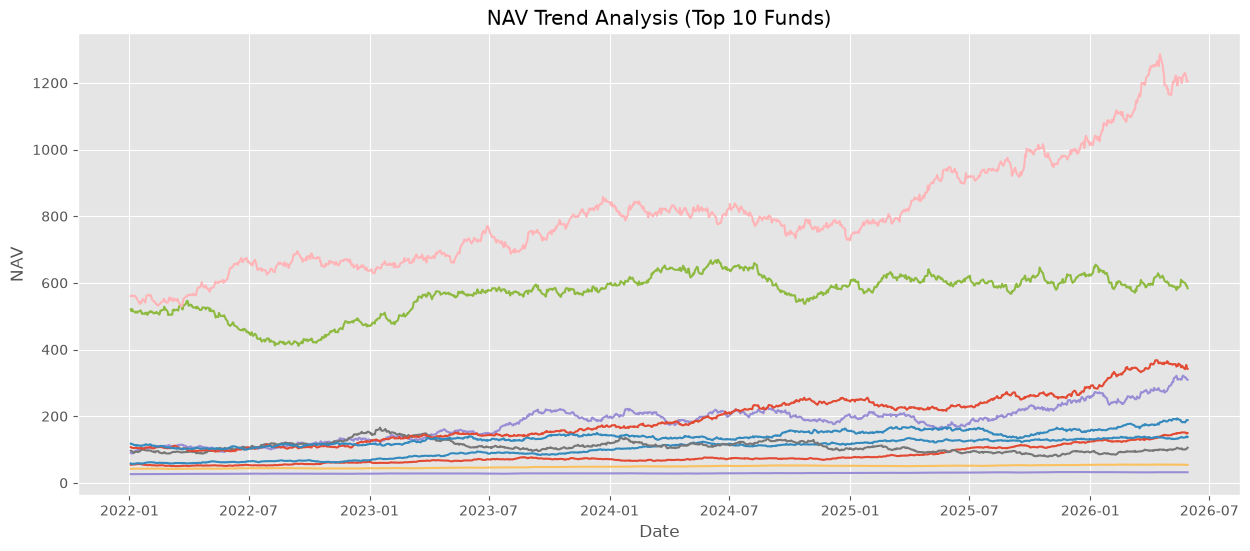

In [16]:
plt.figure(figsize=(15,6))

for fund in nav_history['amfi_code'].unique()[:10]:
    temp = nav_history[nav_history['amfi_code'] == fund]
    plt.plot(temp['date'], temp['nav'])

plt.title("NAV Trend Analysis (Top 10 Funds)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)

plt.show()

In [17]:
scheme_performance = pd.read_csv(
    "Data/processed/scheme_performance_clean.csv"
)

scheme_performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [18]:
scheme_performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

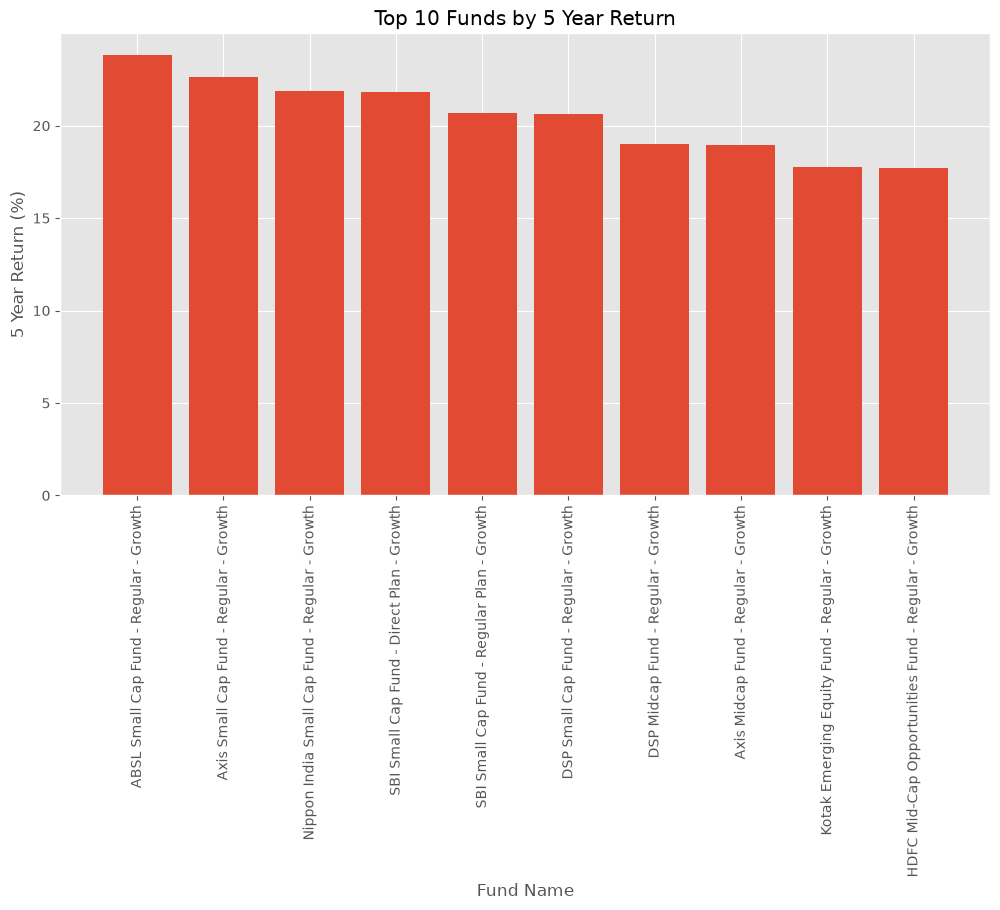

In [19]:
top_funds = scheme_performance.sort_values(
    by='return_5yr_pct',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_funds['scheme_name'],
    top_funds['return_5yr_pct']
)

plt.xticks(rotation=90)
plt.title("Top 10 Funds by 5 Year Return")
plt.xlabel("Fund Name")
plt.ylabel("5 Year Return (%)")

plt.show()

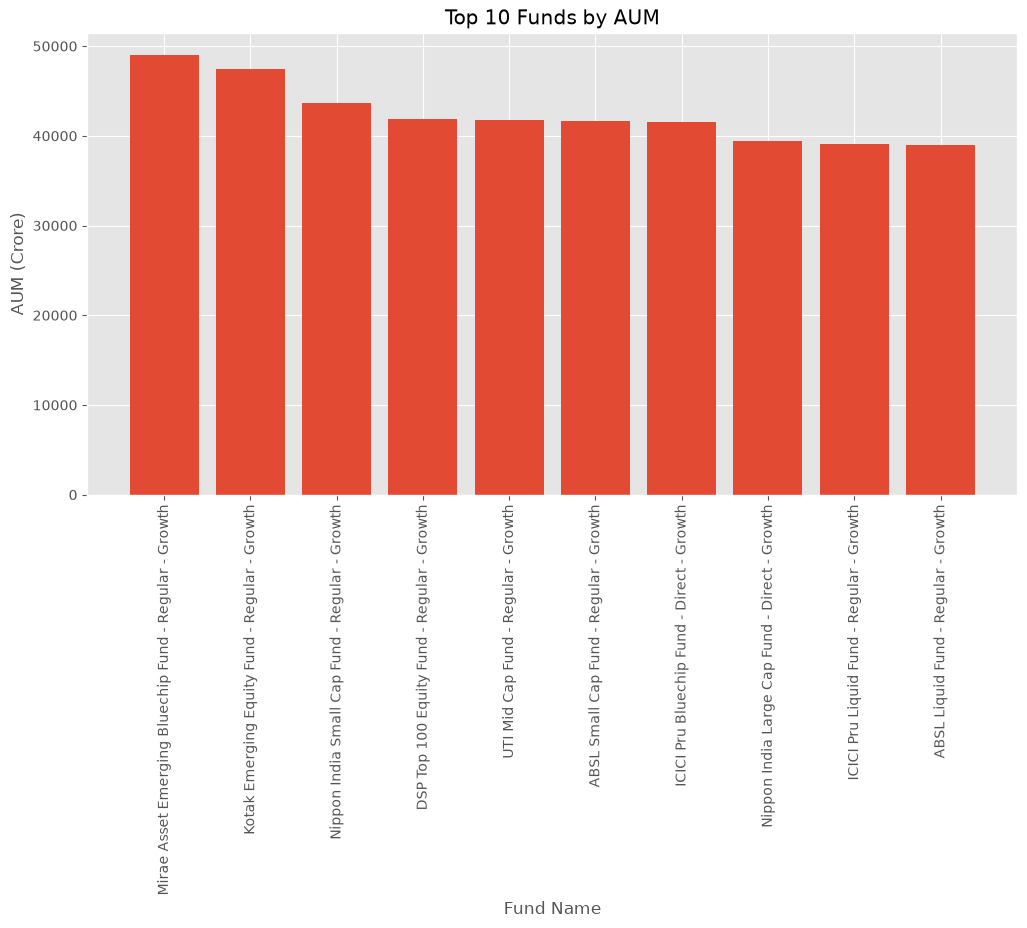

In [20]:
top_aum = scheme_performance.sort_values(
    by='aum_crore',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_aum['scheme_name'],
    top_aum['aum_crore']
)

plt.xticks(rotation=90)
plt.title("Top 10 Funds by AUM")
plt.xlabel("Fund Name")
plt.ylabel("AUM (Crore)")

plt.show()

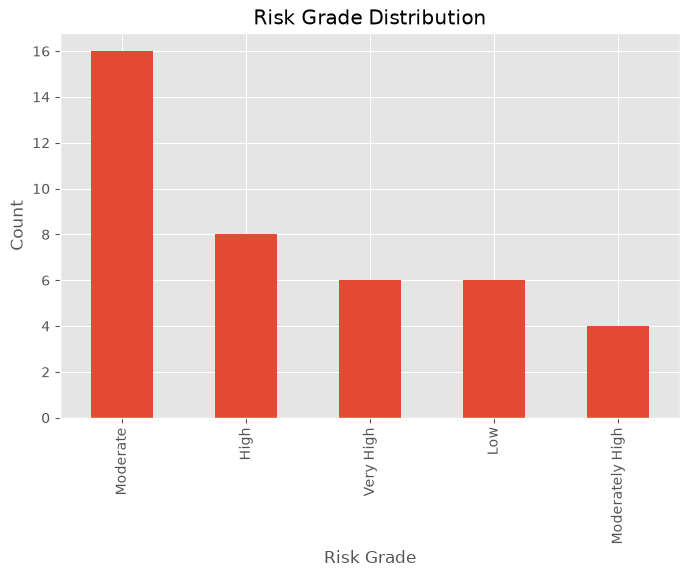

In [21]:
scheme_performance['risk_grade'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Risk Grade Distribution")
plt.xlabel("Risk Grade")
plt.ylabel("Count")

plt.show()

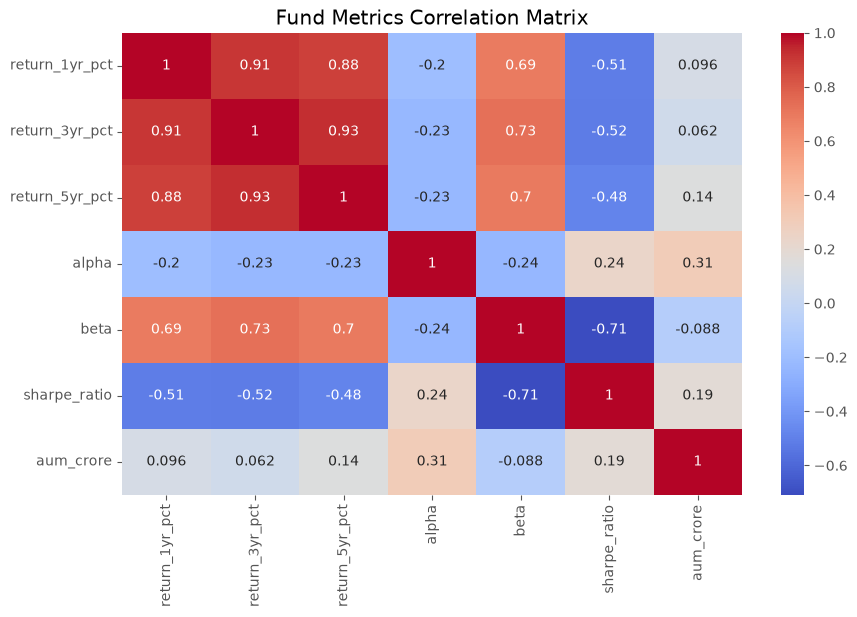

In [22]:
corr_data = scheme_performance[
    [
        'return_1yr_pct',
        'return_3yr_pct',
        'return_5yr_pct',
        'alpha',
        'beta',
        'sharpe_ratio',
        'aum_crore'
    ]
]

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Fund Metrics Correlation Matrix")
plt.show()

# EDA Findings

## Insight 1
5-Year Return aur 3-Year Return me strong positive correlation hai.

## Insight 2
Higher Sharpe Ratio wale funds generally better returns generate karte hain.

## Insight 3
AUM size aur returns ke beech weak relationship dekha gaya.